# Notebook 2 — Variables Aleatorias

## Diplomado de Técnicas Estadísticas — Módulo II

**Alumno:** Cristopher Carlos García  
**Módulo:** II — Probabilidad y Simulación  
**Tema:** Variables Aleatorias (discretas y continuas), Simulación, FGM, Función Característica, LGN y TCL  
**Fecha:** Junio 2026

---

En este notebook estudiamos el concepto de **variable aleatoria** y sus principales
distribuciones, tanto **discretas** como **continuas**. Para cada distribución presentamos su
definición, función de probabilidad o densidad, esperanza, varianza, una visualización y un
ejercicio o simulación. Posteriormente abordamos la **simulación por transformada inversa**, la
**Función Generadora de Momentos (FGM)**, la **Función Característica (FC)**, la **Ley de los
Grandes Números (LGN)** y el **Teorema Central del Límite (TCL)**.


## 0. Librerías utilizadas

Cargamos las librerías de trabajo. Usamos `scipy.stats` para las distribuciones teóricas y
`sympy` para el cálculo simbólico de la FGM. Fijamos una **semilla** para reproducibilidad.


In [1]:
# Importamos las librerías necesarias
import numpy as np                    # cálculo numérico y generación de aleatorios
import matplotlib.pyplot as plt       # gráficas
import scipy.stats as st              # distribuciones de probabilidad teóricas
import sympy as sp                    # cálculo simbólico (FGM y derivadas)

# Fijamos la semilla para reproducibilidad de las simulaciones
np.random.seed(42)

# Estilo general de las gráficas
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. ¿Qué es una variable aleatoria?

Una **variable aleatoria** $X$ es una función que asigna a cada resultado $\omega$ del espacio
muestral $\Omega$ un número real:

$$ X : \Omega \longrightarrow \mathbb{R}, \qquad \omega \mapsto X(\omega). $$

- Es **discreta** si toma valores en un conjunto numerable (por ejemplo $\{0,1,2,\dots\}$). Se
  describe por su **función de masa de probabilidad** $p_X(x) = P(X = x)$.
- Es **continua** si puede tomar cualquier valor en un intervalo de $\mathbb{R}$. Se describe por
  su **función de densidad** $f_X(x)$, con $P(a \le X \le b) = \int_a^b f_X(x)\,dx$.

En ambos casos la **función de distribución acumulada** es $F_X(x) = P(X \le x)$.

Las cantidades resumen más importantes son la **esperanza** y la **varianza**:

$$ E(X) = \sum_x x\, p_X(x) \quad\text{o}\quad \int_{-\infty}^{\infty} x\, f_X(x)\,dx,
\qquad \operatorname{Var}(X) = E(X^2) - [E(X)]^2. $$


# Parte A — Variables aleatorias discretas

A continuación revisamos siete distribuciones discretas fundamentales. Para cada una se muestra
su función de masa, su esperanza y varianza teóricas, una gráfica de la función de masa y un
ejercicio resuelto.


## A.1 Distribución Uniforme discreta

Modela un experimento con $n$ resultados **equiprobables** $\{a, a+1, \dots, b\}$, con
$n = b - a + 1$.

$$ p_X(x) = \frac{1}{n}, \quad x \in \{a,\dots,b\}. $$

$$ E(X) = \frac{a+b}{2}, \qquad \operatorname{Var}(X) = \frac{n^2 - 1}{12}. $$

**Ejemplo:** el lanzamiento de un dado justo ($a=1,\ b=6$).


E(X)   = 3.5
Var(X) = 2.9167
E(X) con scipy   = 3.5
Var(X) con scipy = 2.9166666666666665


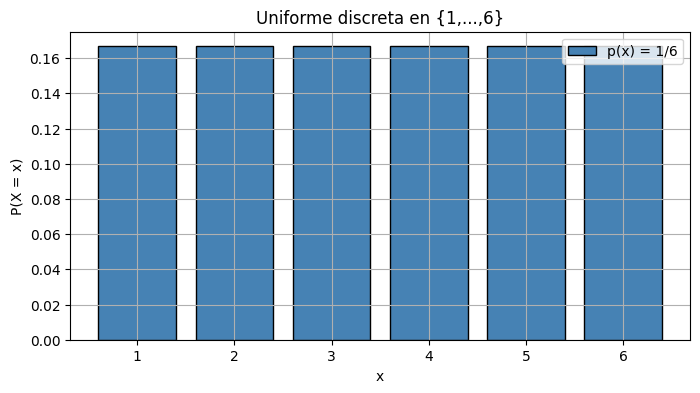

In [2]:
# Distribución Uniforme discreta en {1,...,6} (un dado justo)
a, b = 1, 6
n = b - a + 1
x = np.arange(a, b + 1)                 # soporte de la variable
px = np.full(n, 1 / n)                   # cada valor tiene probabilidad 1/n

# Esperanza y varianza teóricas
E = (a + b) / 2
Var = (n**2 - 1) / 12
print(f"E(X)   = {E}")
print(f"Var(X) = {Var:.4f}")

# Verificación con scipy (randint incluye a, excluye b+1)
print("E(X) con scipy   =", st.randint.mean(a, b + 1))
print("Var(X) con scipy =", st.randint.var(a, b + 1))

# Gráfica de la función de masa
plt.figure()
plt.bar(x, px, color='steelblue', edgecolor='black', label='p(x) = 1/6')
plt.title('Uniforme discreta en {1,...,6}')
plt.xlabel('x'); plt.ylabel('P(X = x)')
plt.legend(); plt.show()

## A.2 Distribución Bernoulli

Modela un experimento con dos resultados: **éxito** (1) con probabilidad $p$ y **fracaso** (0)
con probabilidad $1-p$.

$$ p_X(x) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\}. $$

$$ E(X) = p, \qquad \operatorname{Var}(X) = p(1-p). $$

**Ejemplo:** una moneda cargada con $p = 0.3$ de obtener cara.


E(X)   = 0.3
Var(X) = 0.2100
Proporción de éxitos simulada = 0.2887 (teórica = 0.3)


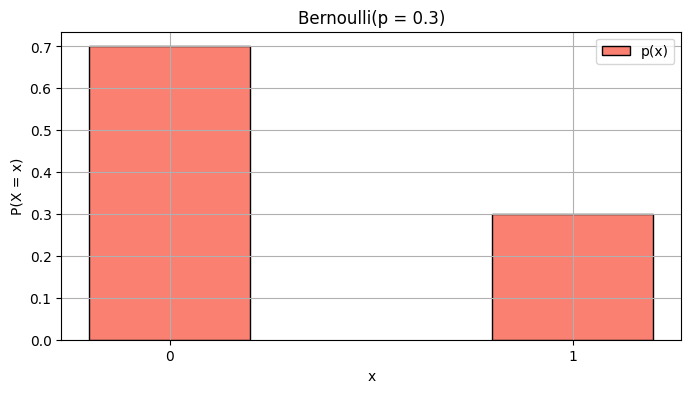

In [3]:
# Distribución Bernoulli con p = 0.3
p = 0.3
x = np.array([0, 1])
px = st.bernoulli.pmf(x, p)              # función de masa

print(f"E(X)   = {st.bernoulli.mean(p)}")
print(f"Var(X) = {st.bernoulli.var(p):.4f}")

# Ejercicio: simulamos 10000 ensayos y comparamos la proporción de éxitos
muestra = st.bernoulli.rvs(p, size=10000)
print(f"Proporción de éxitos simulada = {muestra.mean():.4f} (teórica = {p})")

plt.figure()
plt.bar(x, px, color='salmon', edgecolor='black', width=0.4, label='p(x)')
plt.title('Bernoulli(p = 0.3)')
plt.xlabel('x'); plt.ylabel('P(X = x)')
plt.xticks([0, 1]); plt.legend(); plt.show()

## A.3 Distribución Binomial

Cuenta el número de **éxitos** en $n$ ensayos Bernoulli independientes con probabilidad $p$.

$$ p_X(x) = \binom{n}{x} p^x (1-p)^{n-x}, \quad x = 0, 1, \dots, n. $$

$$ E(X) = np, \qquad \operatorname{Var}(X) = np(1-p). $$

**Ejercicio:** un examen de 12 preguntas de opción múltiple con 4 opciones cada una
($p = 1/4$). Calculamos $P(X = 3)$ y $P(X \ge 6)$ respondiendo al azar.


E(X)   = 3.0
Var(X) = 2.2500
P(X = 3)  = 0.2581
P(X >= 6) = 0.0544


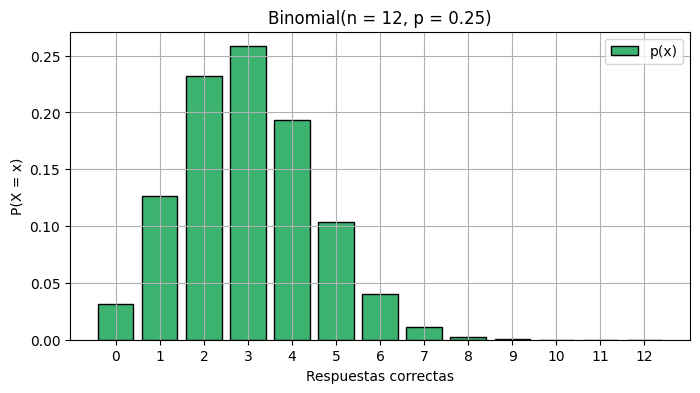

In [4]:
# Distribución Binomial: examen de n=12 preguntas, p=1/4
n, p = 12, 0.25
x = np.arange(0, n + 1)
px = st.binom.pmf(x, n, p)

print(f"E(X)   = {st.binom.mean(n, p)}")
print(f"Var(X) = {st.binom.var(n, p):.4f}")

# Probabilidades pedidas
P_3   = st.binom.pmf(3, n, p)
P_ge6 = 1 - st.binom.cdf(5, n, p)
print(f"P(X = 3)  = {P_3:.4f}")
print(f"P(X >= 6) = {P_ge6:.4f}")

plt.figure()
plt.bar(x, px, color='mediumseagreen', edgecolor='black', label='p(x)')
plt.title('Binomial(n = 12, p = 0.25)')
plt.xlabel('Respuestas correctas'); plt.ylabel('P(X = x)')
plt.xticks(x); plt.legend(); plt.show()

## A.4 Distribución Geométrica

Cuenta el número de ensayos Bernoulli hasta obtener el **primer éxito** (soporte
$\{1, 2, 3, \dots\}$).

$$ p_X(x) = (1-p)^{x-1} p, \quad x = 1, 2, 3, \dots $$

$$ E(X) = \frac{1}{p}, \qquad \operatorname{Var}(X) = \frac{1-p}{p^2}. $$

**Ejemplo:** número de lanzamientos de un dado hasta obtener el primer 6 ($p = 1/6$).


E(X)   = 6.0000
Var(X) = 30.0000
P(X = 3) = 0.1157


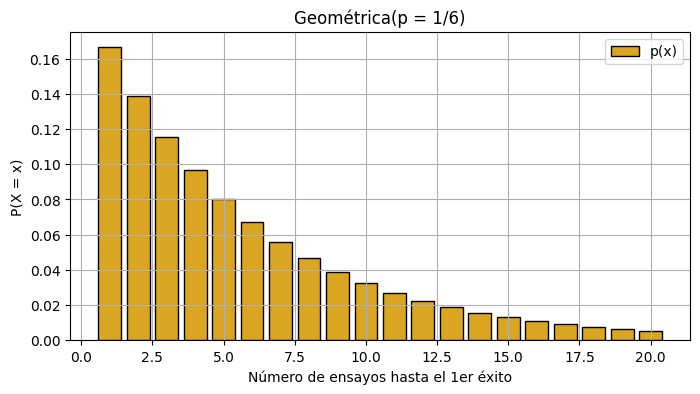

In [5]:
# Distribución Geométrica con p = 1/6 (primer 6 al lanzar un dado)
p = 1 / 6
x = np.arange(1, 21)
px = st.geom.pmf(x, p)

print(f"E(X)   = {st.geom.mean(p):.4f}")
print(f"Var(X) = {st.geom.var(p):.4f}")

# Ejercicio: probabilidad de necesitar exactamente 3 lanzamientos
print(f"P(X = 3) = {st.geom.pmf(3, p):.4f}")

plt.figure()
plt.bar(x, px, color='goldenrod', edgecolor='black', label='p(x)')
plt.title('Geométrica(p = 1/6)')
plt.xlabel('Número de ensayos hasta el 1er éxito'); plt.ylabel('P(X = x)')
plt.legend(); plt.show()

## A.5 Distribución de Poisson

Modela el número de **eventos** que ocurren en un intervalo fijo de tiempo o espacio, con tasa
media $\lambda$.

$$ p_X(x) = \frac{e^{-\lambda}\, \lambda^{x}}{x!}, \quad x = 0, 1, 2, \dots $$

$$ E(X) = \lambda, \qquad \operatorname{Var}(X) = \lambda. $$

**Ejercicio:** una central recibe en promedio $\lambda = 4$ llamadas por minuto. Calculamos
$P(X = 2)$ y $P(X \le 3)$.


E(X)   = 4.0
Var(X) = 4.0
P(X = 2)  = 0.1465
P(X <= 3) = 0.4335


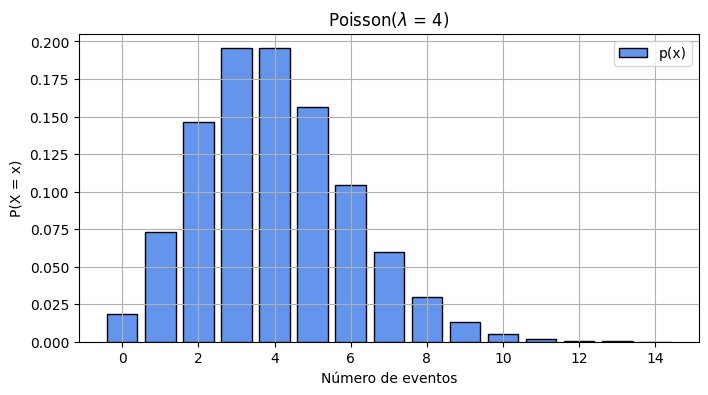

In [6]:
# Distribución de Poisson con lambda = 4 llamadas por minuto
lam = 4
x = np.arange(0, 15)
px = st.poisson.pmf(x, lam)

print(f"E(X)   = {st.poisson.mean(lam)}")
print(f"Var(X) = {st.poisson.var(lam)}")

print(f"P(X = 2)  = {st.poisson.pmf(2, lam):.4f}")
print(f"P(X <= 3) = {st.poisson.cdf(3, lam):.4f}")

plt.figure()
plt.bar(x, px, color='cornflowerblue', edgecolor='black', label='p(x)')
plt.title('Poisson($\\lambda$ = 4)')
plt.xlabel('Número de eventos'); plt.ylabel('P(X = x)')
plt.legend(); plt.show()

## A.6 Distribución Binomial negativa

Cuenta el número de **fracasos** antes de alcanzar el $r$-ésimo éxito, con probabilidad de éxito
$p$ (parametrización de `scipy`).

$$ p_X(x) = \binom{x + r - 1}{x} p^{r} (1-p)^{x}, \quad x = 0, 1, 2, \dots $$

$$ E(X) = \frac{r(1-p)}{p}, \qquad \operatorname{Var}(X) = \frac{r(1-p)}{p^2}. $$

**Ejemplo:** número de fracasos antes de obtener $r = 3$ éxitos con $p = 0.4$.


E(X)   = 4.5000
Var(X) = 11.2500
P(X = 5) = 0.1045


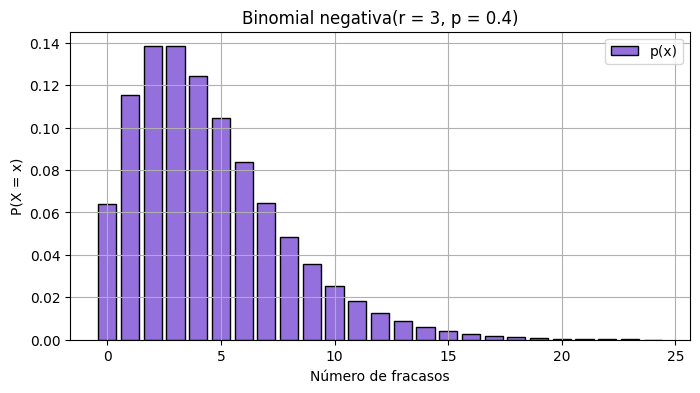

In [7]:
# Distribución Binomial negativa: r = 3 éxitos, p = 0.4
r, p = 3, 0.4
x = np.arange(0, 25)
px = st.nbinom.pmf(x, r, p)

print(f"E(X)   = {st.nbinom.mean(r, p):.4f}")
print(f"Var(X) = {st.nbinom.var(r, p):.4f}")

# Ejercicio: probabilidad de observar exactamente 5 fracasos antes del 3er éxito
print(f"P(X = 5) = {st.nbinom.pmf(5, r, p):.4f}")

plt.figure()
plt.bar(x, px, color='mediumpurple', edgecolor='black', label='p(x)')
plt.title('Binomial negativa(r = 3, p = 0.4)')
plt.xlabel('Número de fracasos'); plt.ylabel('P(X = x)')
plt.legend(); plt.show()

## A.7 Distribución Hipergeométrica

Modela el número de éxitos en $n$ extracciones **sin reemplazo** de una población de tamaño $N$
que contiene $K$ éxitos.

$$ p_X(x) = \frac{\binom{K}{x}\binom{N-K}{n-x}}{\binom{N}{n}}. $$

$$ E(X) = n\frac{K}{N}, \qquad \operatorname{Var}(X) = n\frac{K}{N}\frac{N-K}{N}\frac{N-n}{N-1}. $$

**Ejercicio:** una urna con $N = 50$ objetos, de los cuales $K = 20$ son defectuosos. Se
extraen $n = 10$ sin reemplazo. Distribución del número de defectuosos.


E(X)   = 4.0000
Var(X) = 1.9592
P(X = 4) = 0.2801


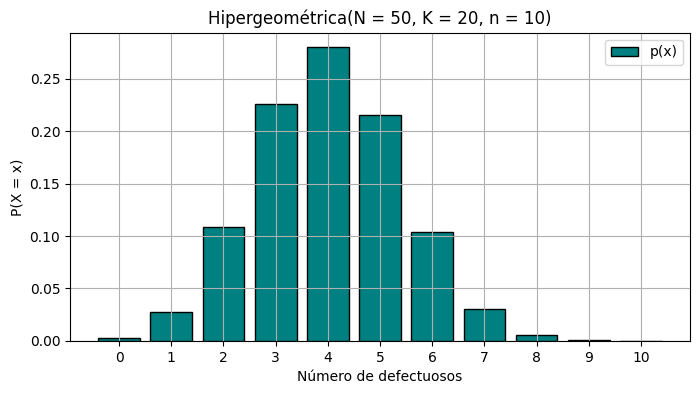

In [8]:
# Distribución Hipergeométrica: N=50, K=20 defectuosos, n=10 extracciones
N, K, n = 50, 20, 10
x = np.arange(0, n + 1)
# scipy usa (M=N, n=K, N=n): M población, n éxitos, N extracciones
px = st.hypergeom.pmf(x, N, K, n)

print(f"E(X)   = {st.hypergeom.mean(N, K, n):.4f}")
print(f"Var(X) = {st.hypergeom.var(N, K, n):.4f}")

# Ejercicio: probabilidad de extraer exactamente 4 defectuosos
print(f"P(X = 4) = {st.hypergeom.pmf(4, N, K, n):.4f}")

plt.figure()
plt.bar(x, px, color='teal', edgecolor='black', label='p(x)')
plt.title('Hipergeométrica(N = 50, K = 20, n = 10)')
plt.xlabel('Número de defectuosos'); plt.ylabel('P(X = x)')
plt.xticks(x); plt.legend(); plt.show()

# Parte B — Variables aleatorias continuas

Ahora revisamos cuatro distribuciones continuas fundamentales. Para cada una mostramos su
función de densidad $f_X(x)$ y su función de distribución $F_X(x)$, su esperanza y varianza, una
gráfica de la PDF y la CDF, y una **simulación** que comparamos con la teoría mediante un
histograma.


## B.1 Distribución Uniforme continua

Todos los valores del intervalo $[a, b]$ son igualmente probables.

$$ f_X(x) = \frac{1}{b-a},\ x \in [a,b]; \qquad
F_X(x) = \frac{x-a}{b-a},\ x \in [a,b]. $$

$$ E(X) = \frac{a+b}{2}, \qquad \operatorname{Var}(X) = \frac{(b-a)^2}{12}. $$


E(X)   = 5.0
Var(X) = 3.0000


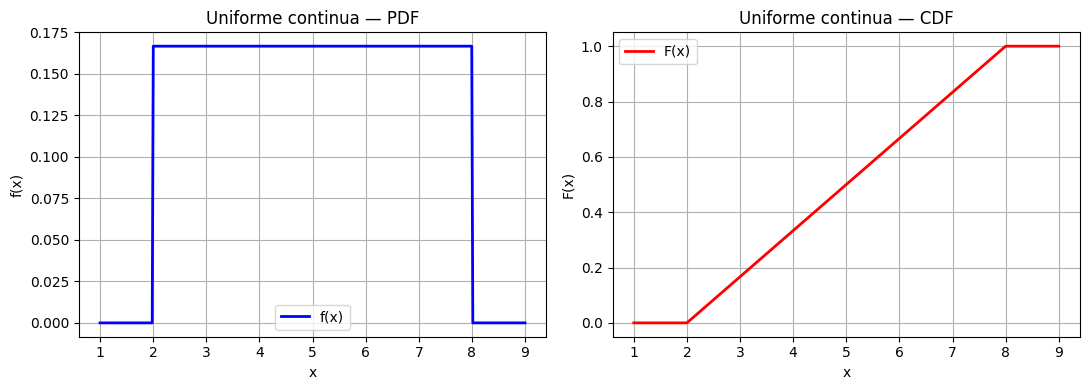

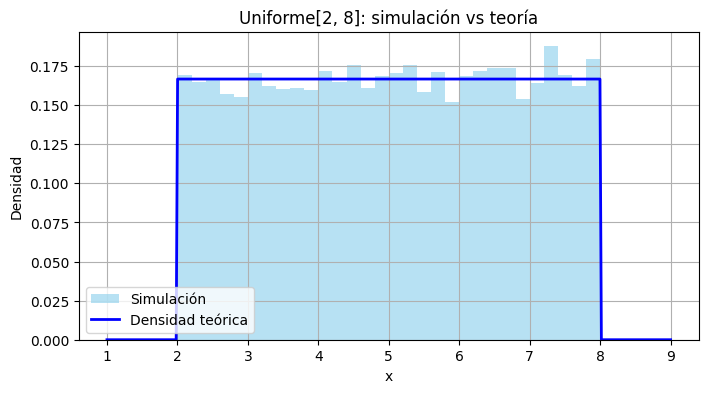

Media simulada = 5.0272


In [9]:
# Uniforme continua en [2, 8]
a, b = 2, 8
dist = st.uniform(loc=a, scale=b - a)
x = np.linspace(a - 1, b + 1, 400)

print(f"E(X)   = {dist.mean()}")
print(f"Var(X) = {dist.var():.4f}")

# Gráfica de PDF y CDF
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, dist.pdf(x), 'b-', lw=2, label='f(x)')
ax[0].set_title('Uniforme continua — PDF'); ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)')
ax[0].legend()
ax[1].plot(x, dist.cdf(x), 'r-', lw=2, label='F(x)')
ax[1].set_title('Uniforme continua — CDF'); ax[1].set_xlabel('x'); ax[1].set_ylabel('F(x)')
ax[1].legend()
plt.tight_layout(); plt.show()

# Simulación vs teoría
muestra = dist.rvs(size=10000)
plt.figure()
plt.hist(muestra, bins=30, density=True, alpha=0.6, color='skyblue', label='Simulación')
plt.plot(x, dist.pdf(x), 'b-', lw=2, label='Densidad teórica')
plt.title('Uniforme[2, 8]: simulación vs teoría')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend(); plt.show()

print(f"Media simulada = {muestra.mean():.4f}")

## B.2 Distribución Normal

La distribución más importante de la estadística, con parámetros media $\mu$ y desviación
$\sigma$.

$$ f_X(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{(x-\mu)^2}{2\sigma^2}}, \quad x \in \mathbb{R}. $$

La CDF $F_X(x)$ no tiene forma cerrada elemental; se expresa con la función $\Phi$.

$$ E(X) = \mu, \qquad \operatorname{Var}(X) = \sigma^2. $$


E(X)   = 100.0
Var(X) = 225.0
P(mu-sigma < X < mu+sigma) = 0.6827  (~0.68)


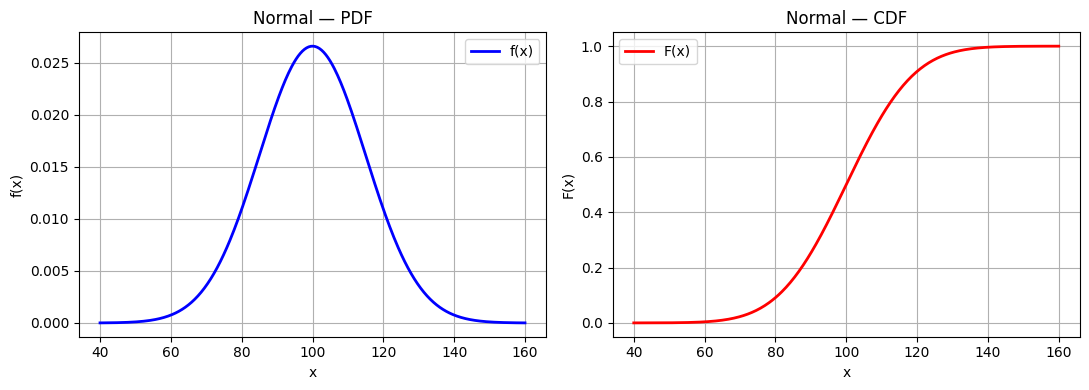

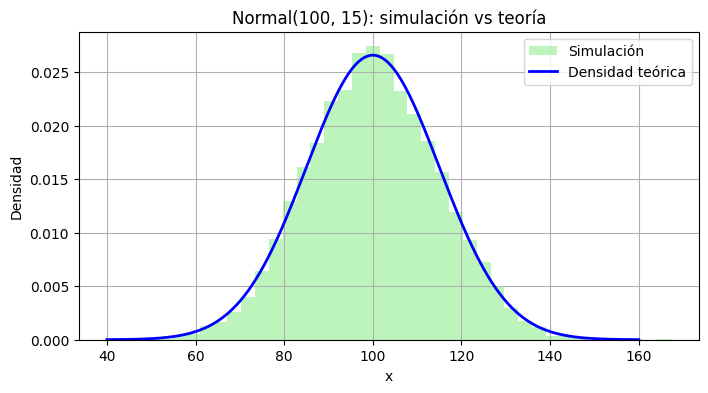

In [10]:
# Distribución Normal con mu = 100, sigma = 15 (ej. coeficiente intelectual)
mu, sigma = 100, 15
dist = st.norm(mu, sigma)
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)

print(f"E(X)   = {dist.mean()}")
print(f"Var(X) = {dist.var()}")

# Regla empírica: P(mu - sigma < X < mu + sigma)
p1 = dist.cdf(mu + sigma) - dist.cdf(mu - sigma)
print(f"P(mu-sigma < X < mu+sigma) = {p1:.4f}  (~0.68)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, dist.pdf(x), 'b-', lw=2, label='f(x)')
ax[0].set_title('Normal — PDF'); ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)'); ax[0].legend()
ax[1].plot(x, dist.cdf(x), 'r-', lw=2, label='F(x)')
ax[1].set_title('Normal — CDF'); ax[1].set_xlabel('x'); ax[1].set_ylabel('F(x)'); ax[1].legend()
plt.tight_layout(); plt.show()

# Simulación vs teoría
muestra = dist.rvs(size=10000)
plt.figure()
plt.hist(muestra, bins=40, density=True, alpha=0.6, color='lightgreen', label='Simulación')
plt.plot(x, dist.pdf(x), 'b-', lw=2, label='Densidad teórica')
plt.title('Normal(100, 15): simulación vs teoría')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend(); plt.show()

## B.3 Distribución Exponencial

Modela el **tiempo de espera** hasta que ocurre un evento en un proceso de Poisson con tasa
$\lambda$.

$$ f_X(x) = \lambda e^{-\lambda x},\ x \ge 0; \qquad F_X(x) = 1 - e^{-\lambda x},\ x \ge 0. $$

$$ E(X) = \frac{1}{\lambda}, \qquad \operatorname{Var}(X) = \frac{1}{\lambda^2}. $$


E(X)   = 2.0
Var(X) = 4.0
P(X > 3) = 0.2231


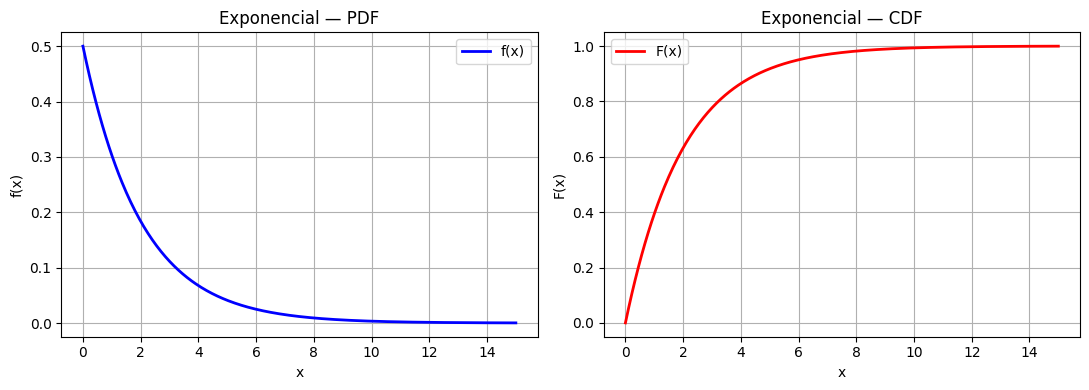

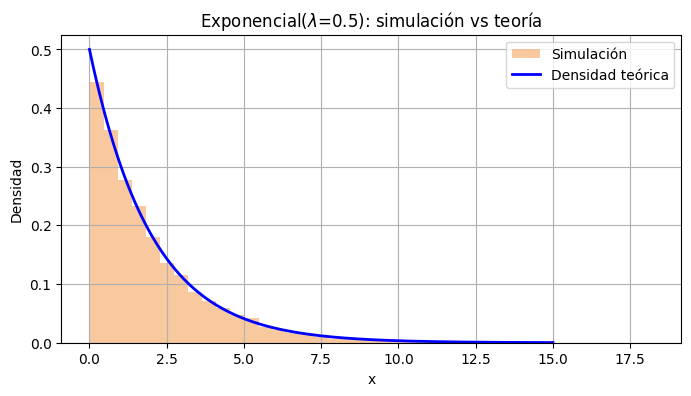

In [11]:
# Exponencial con lambda = 0.5 (scipy usa scale = 1/lambda)
lam = 0.5
dist = st.expon(scale=1 / lam)
x = np.linspace(0, 15, 400)

print(f"E(X)   = {dist.mean()}")
print(f"Var(X) = {dist.var()}")
print(f"P(X > 3) = {dist.sf(3):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, dist.pdf(x), 'b-', lw=2, label='f(x)')
ax[0].set_title('Exponencial — PDF'); ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)'); ax[0].legend()
ax[1].plot(x, dist.cdf(x), 'r-', lw=2, label='F(x)')
ax[1].set_title('Exponencial — CDF'); ax[1].set_xlabel('x'); ax[1].set_ylabel('F(x)'); ax[1].legend()
plt.tight_layout(); plt.show()

muestra = dist.rvs(size=10000)
plt.figure()
plt.hist(muestra, bins=40, density=True, alpha=0.6, color='sandybrown', label='Simulación')
plt.plot(x, dist.pdf(x), 'b-', lw=2, label='Densidad teórica')
plt.title('Exponencial($\\lambda$=0.5): simulación vs teoría')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend(); plt.show()

## B.4 Distribución Gamma

Generaliza la exponencial: modela el tiempo hasta el $k$-ésimo evento. Parámetros de forma
$k$ (o $\alpha$) y escala $\theta$.

$$ f_X(x) = \frac{1}{\Gamma(k)\,\theta^{k}}\, x^{k-1} e^{-x/\theta}, \quad x > 0. $$

$$ E(X) = k\theta, \qquad \operatorname{Var}(X) = k\theta^{2}. $$


E(X)   = 6.0
Var(X) = 12.0


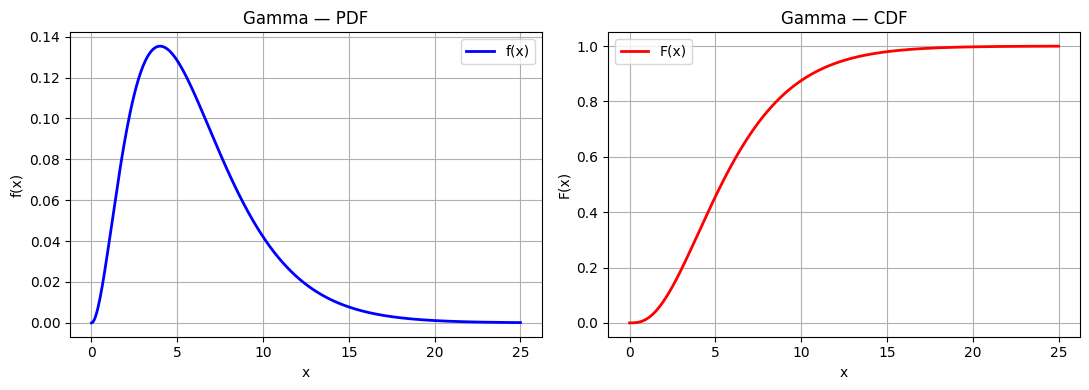

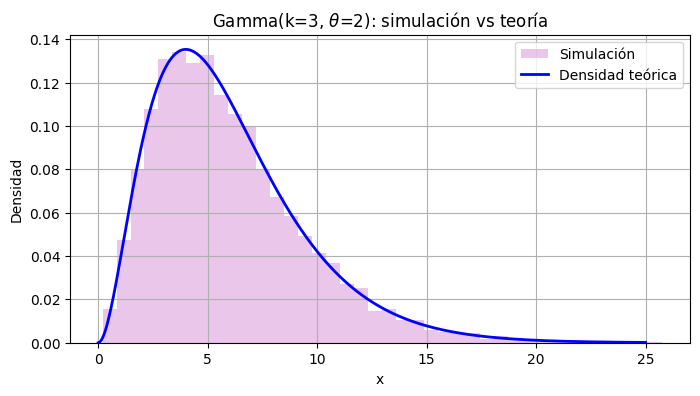

In [12]:
# Distribución Gamma con forma k = 3 y escala theta = 2
k, theta = 3, 2
dist = st.gamma(a=k, scale=theta)
x = np.linspace(0, 25, 400)

print(f"E(X)   = {dist.mean()}")
print(f"Var(X) = {dist.var()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, dist.pdf(x), 'b-', lw=2, label='f(x)')
ax[0].set_title('Gamma — PDF'); ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)'); ax[0].legend()
ax[1].plot(x, dist.cdf(x), 'r-', lw=2, label='F(x)')
ax[1].set_title('Gamma — CDF'); ax[1].set_xlabel('x'); ax[1].set_ylabel('F(x)'); ax[1].legend()
plt.tight_layout(); plt.show()

muestra = dist.rvs(size=10000)
plt.figure()
plt.hist(muestra, bins=40, density=True, alpha=0.6, color='plum', label='Simulación')
plt.plot(x, dist.pdf(x), 'b-', lw=2, label='Densidad teórica')
plt.title('Gamma(k=3, $\\theta$=2): simulación vs teoría')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend(); plt.show()

# Parte C — Simulación por transformada inversa

## C.1 Método de la transformada inversa

**Teorema.** Si $U \sim \text{Uniforme}(0,1)$ y $F_X$ es la función de distribución de $X$
(estrictamente creciente), entonces la variable

$$ X = F_X^{-1}(U) $$

tiene distribución $F_X$. Este resultado permite **generar variables aleatorias** de cualquier
distribución de la que sepamos invertir su CDF, partiendo únicamente de números uniformes.

**Procedimiento general:**
1. Generar $u \sim U(0,1)$.
2. Resolver $u = F_X(x)$ para $x$, es decir calcular $x = F_X^{-1}(u)$.
3. El valor $x$ obtenido es una realización de $X$.


### Ejemplo 1 — Exponencial por transformada inversa

Para la exponencial $F_X(x) = 1 - e^{-\lambda x}$. Despejando:

$$ u = 1 - e^{-\lambda x} \;\Longrightarrow\; x = -\frac{1}{\lambda}\ln(1-u). $$


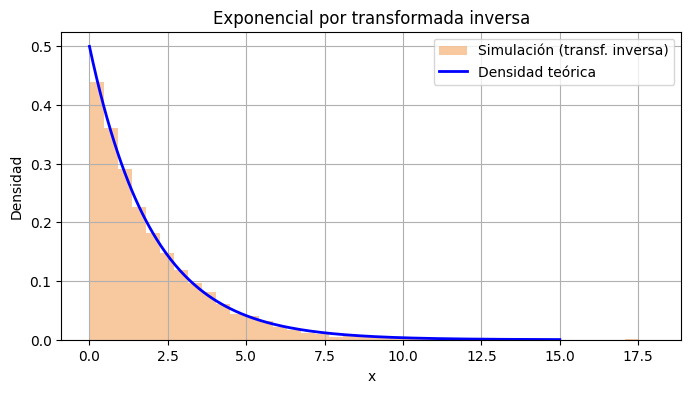

Media simulada = 1.9762  (teórica = 2.0)


In [13]:
# Simulación de la Exponencial por transformada inversa
lam = 0.5
n = 10000
u = np.random.uniform(0, 1, n)          # uniformes en (0,1)
x_sim = -np.log(1 - u) / lam            # transformada inversa: F^{-1}(u)

# Comparación con la densidad teórica
x = np.linspace(0, 15, 400)
plt.figure()
plt.hist(x_sim, bins=40, density=True, alpha=0.6, color='sandybrown',
         label='Simulación (transf. inversa)')
plt.plot(x, st.expon(scale=1 / lam).pdf(x), 'b-', lw=2, label='Densidad teórica')
plt.title('Exponencial por transformada inversa')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend(); plt.show()

print(f"Media simulada = {x_sim.mean():.4f}  (teórica = {1/lam})")

### Ejemplo 2 — Distribución de Cauchy por transformada inversa

La distribución de **Cauchy estándar** (parámetro 1) tiene densidad y distribución:

$$ f_X(x) = \frac{1}{\pi}\,\frac{1}{1+x^2}, \qquad
F_X(x) = \frac{1}{\pi}\arctan(x) + \frac{1}{2}, \quad x \in \mathbb{R}. $$

Al despejar $x$ de $u = F_X(x)$ obtenemos la fórmula de generación (usada en los notebooks de
clase):

$$ x = \tan\!\left(\pi\left(u - \tfrac{1}{2}\right)\right). $$

**Nota:** la Cauchy es un ejemplo notable de distribución **sin esperanza ni varianza** finitas
(la integral que las define diverge); por eso su media muestral no se estabiliza.


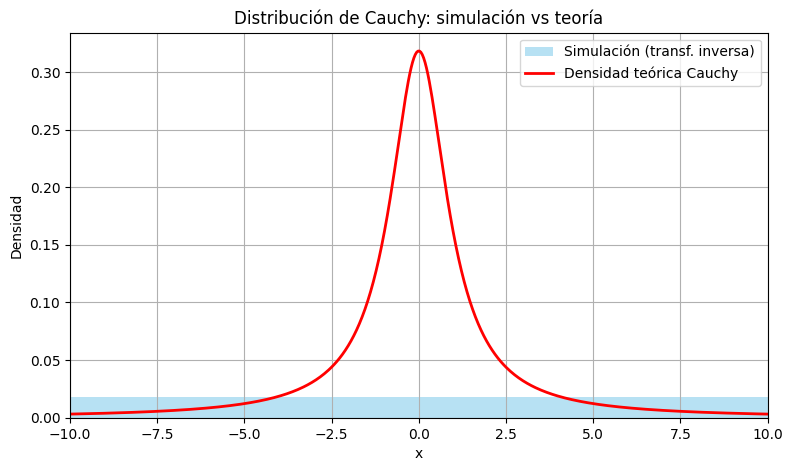

Mediana simulada = 0.0069  (teórica = 0)
Media simulada   = -0.9271  (no está definida teóricamente)


In [14]:
# Simulación de la Cauchy estándar por transformada inversa
n = 100000
u = np.random.uniform(0, 1, n)
cauchy_sim = np.tan(np.pi * (u - 0.5))   # x = tan(pi (u - 1/2))

# Densidad teórica de Cauchy
x = np.linspace(-10, 10, 500)
y_teo = 1 / (np.pi * (1 + x**2))

plt.figure(figsize=(9, 5))
# Recortamos a [-10,10] solo para visualizar (la Cauchy tiene colas muy pesadas)
plt.hist(cauchy_sim, bins=2000, density=True, alpha=0.6, color='skyblue',
         label='Simulación (transf. inversa)')
plt.plot(x, y_teo, 'r-', lw=2, label='Densidad teórica Cauchy')
plt.xlim(-10, 10)
plt.title('Distribución de Cauchy: simulación vs teoría')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend(); plt.show()

# La mediana sí existe y es 0; la media no converge
print(f"Mediana simulada = {np.median(cauchy_sim):.4f}  (teórica = 0)")
print(f"Media simulada   = {cauchy_sim.mean():.4f}  (no está definida teóricamente)")

**Verificación de que $f_X$ es densidad de probabilidad.** Comprobamos numéricamente que
$\int_{\mathbb{R}} f_X(x)\,dx = 1$ para la Cauchy.


In [15]:
# Verificación de que la densidad de Cauchy integra 1
from scipy.integrate import quad
f_cauchy = lambda x: 1 / (np.pi * (1 + x**2))
integral, _ = quad(f_cauchy, -np.inf, np.inf)
print(f"Integral de f_X sobre R = {integral:.6f}  (debe ser 1)")

Integral de f_X sobre R = 1.000000  (debe ser 1)


# Parte D — Función Generadora de Momentos (FGM)

## D.1 Definición

La **función generadora de momentos** de una variable aleatoria $X$ es

$$ M_X(t) = E\!\left(e^{tX}\right), $$

siempre que la esperanza exista para $t$ en un entorno de $0$.

**Propiedades:**
1. Los momentos se obtienen derivando y evaluando en $t = 0$:
   $$ E(X^n) = M_X^{(n)}(0). $$
   En particular $E(X) = M_X'(0)$ y $E(X^2) = M_X''(0)$.
2. La FGM **caracteriza** la distribución: si dos variables tienen la misma FGM, tienen la misma
   distribución.
3. Para variables independientes, $M_{X+Y}(t) = M_X(t)\,M_Y(t)$.


### D.2 Ejemplo simbólico — FGM de la Poisson

Para $X \sim \text{Poisson}(\lambda)$ se tiene

$$ M_X(t) = e^{\lambda\left(e^{t}-1\right)}. $$

Usamos `sympy` para derivar y obtener $E(X)$ y $\operatorname{Var}(X)$.


In [16]:
# FGM de la Poisson con sympy
t, lam = sp.symbols('t lambda', positive=True)

M = sp.exp(lam * (sp.exp(t) - 1))        # FGM de la Poisson
print("M_X(t) =", M)

# Primer momento: E(X) = M'(0)
M1 = sp.diff(M, t)
EX = M1.subs(t, 0)
print("E(X)  = M'(0)  =", sp.simplify(EX))

# Segundo momento: E(X^2) = M''(0)
M2 = sp.diff(M, t, 2)
EX2 = M2.subs(t, 0)
print("E(X^2)= M''(0) =", sp.simplify(EX2))

# Varianza = E(X^2) - [E(X)]^2
Var = sp.simplify(EX2 - EX**2)
print("Var(X) = E(X^2) - E(X)^2 =", Var)

M_X(t) = exp(lambda*(exp(t) - 1))
E(X)  = M'(0)  = lambda


E(X^2)= M''(0) = lambda*(lambda + 1)
Var(X) = E(X^2) - E(X)^2 = lambda


### D.3 Ejemplo simbólico — FGM de la Normal

Para $X \sim N(\mu, \sigma^2)$, $\;M_X(t) = \exp\!\left(\mu t + \tfrac{1}{2}\sigma^2 t^2\right)$.
Verificamos que $M_X'(0) = \mu$ y $\operatorname{Var}(X) = \sigma^2$.


In [17]:
# FGM de la Normal con sympy
t = sp.symbols('t')
mu, sigma = sp.symbols('mu sigma', positive=True)

M = sp.exp(mu * t + sigma**2 * t**2 / 2)   # FGM de la Normal
EX = sp.diff(M, t).subs(t, 0)
EX2 = sp.diff(M, t, 2).subs(t, 0)
Var = sp.simplify(EX2 - EX**2)
print("E(X)   =", sp.simplify(EX))
print("Var(X) =", Var)

E(X)   = mu
Var(X) = sigma**2


# Parte E — Función Característica (FC)

## E.1 Definición

La **función característica** de $X$ es

$$ \varphi_X(t) = E\!\left(e^{itX}\right), \qquad i = \sqrt{-1}. $$

A diferencia de la FGM, la FC **siempre existe** para toda variable aleatoria (porque
$|e^{itX}| = 1$). También caracteriza por completo la distribución y cumple
$\varphi_{X+Y}(t) = \varphi_X(t)\varphi_Y(t)$ para variables independientes.

### E.2 Ejemplo — FC de la Normal

Para $X \sim N(\mu, \sigma^2)$:

$$ \varphi_X(t) = \exp\!\left(i\mu t - \tfrac{1}{2}\sigma^2 t^2\right). $$

Comprobamos numéricamente que la FC teórica coincide con la FC empírica
$\hat\varphi(t) = \frac{1}{n}\sum_j e^{it x_j}$ calculada a partir de una muestra.


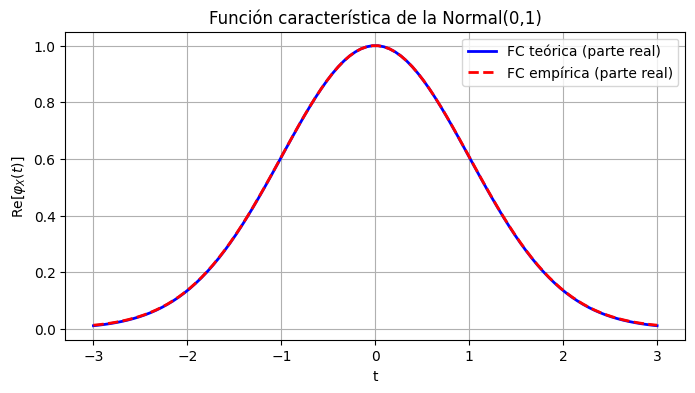

phi(0) = 1.0 (debe ser 1)


In [18]:
# Función característica de la Normal: teórica vs empírica
mu, sigma = 0, 1
muestra = np.random.normal(mu, sigma, 100000)

# FC teórica
phi_teo = lambda t: np.exp(1j * mu * t - 0.5 * sigma**2 * t**2)
# FC empírica a partir de la muestra
phi_emp = lambda t: np.mean(np.exp(1j * t * muestra))

t_vals = np.linspace(-3, 3, 100)
re_teo = [phi_teo(t).real for t in t_vals]
re_emp = [phi_emp(t).real for t in t_vals]

plt.figure()
plt.plot(t_vals, re_teo, 'b-', lw=2, label='FC teórica (parte real)')
plt.plot(t_vals, re_emp, 'r--', lw=2, label='FC empírica (parte real)')
plt.title('Función característica de la Normal(0,1)')
plt.xlabel('t'); plt.ylabel('Re[$\\varphi_X(t)$]'); plt.legend(); plt.show()

print("phi(0) =", phi_emp(0).real, "(debe ser 1)")

# Parte F — Ley de los Grandes Números (LGN)

La **Ley de los Grandes Números** establece que, al aumentar el tamaño de muestra $n$, el
**promedio muestral** converge a la esperanza teórica:

$$ \bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i \;\xrightarrow[n\to\infty]{}\; E(X). $$

**Simulación.** Lanzamos un dado justo (esperanza $E(X) = 3.5$) y observamos cómo el promedio
acumulado se estabiliza en torno a $3.5$ conforme crece $n$.


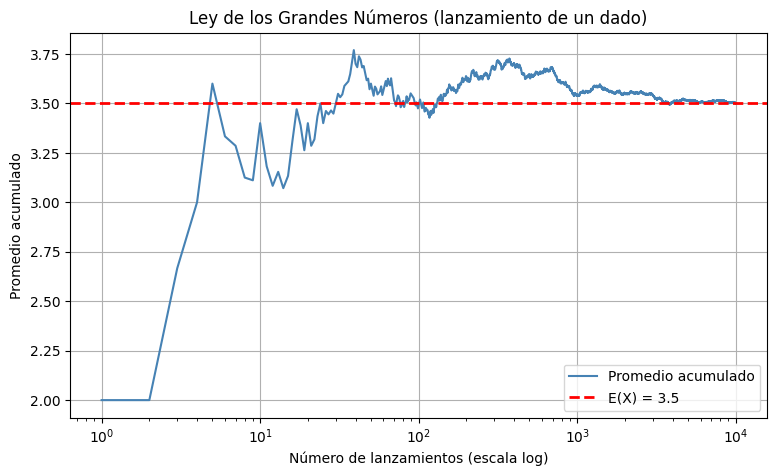

Promedio con n = 10000: 3.4998  (E(X) = 3.5)


In [19]:
# Ley de los Grandes Números con el lanzamiento de un dado
n = 10000
lanzamientos = np.random.randint(1, 7, size=n)     # dado justo {1,...,6}
promedios = np.cumsum(lanzamientos) / np.arange(1, n + 1)   # promedio acumulado
esperanza = 3.5                                     # E(X) teórica

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, n + 1), promedios, color='steelblue', label='Promedio acumulado')
plt.axhline(esperanza, color='red', ls='--', lw=2, label='E(X) = 3.5')
plt.xscale('log')
plt.title('Ley de los Grandes Números (lanzamiento de un dado)')
plt.xlabel('Número de lanzamientos (escala log)'); plt.ylabel('Promedio acumulado')
plt.legend(); plt.show()

print(f"Promedio con n = {n}: {promedios[-1]:.4f}  (E(X) = {esperanza})")

También podemos ver la convergencia comparando el promedio para **distintos tamaños de
muestra**.


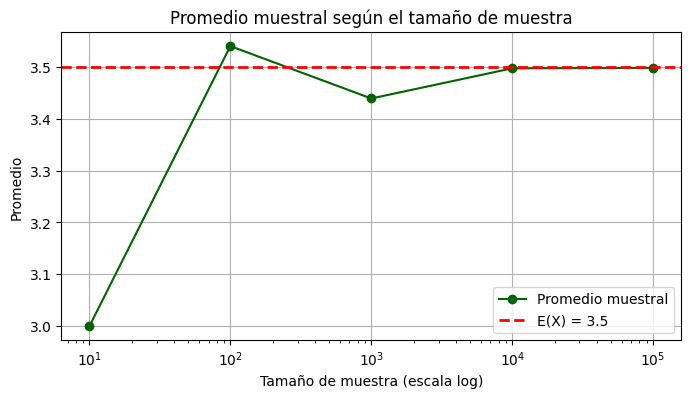

n =     10:  promedio = 3.0000
n =    100:  promedio = 3.5400
n =   1000:  promedio = 3.4390
n =  10000:  promedio = 3.4972
n = 100000:  promedio = 3.4980


In [20]:
# Convergencia del promedio para distintos tamaños de muestra
tam = [10, 100, 1000, 10000, 100000]
medias = [np.random.randint(1, 7, size=m).mean() for m in tam]

plt.figure()
plt.plot(tam, medias, 'o-', color='darkgreen', label='Promedio muestral')
plt.axhline(3.5, color='red', ls='--', lw=2, label='E(X) = 3.5')
plt.xscale('log')
plt.title('Promedio muestral según el tamaño de muestra')
plt.xlabel('Tamaño de muestra (escala log)'); plt.ylabel('Promedio')
plt.legend(); plt.show()

for m, med in zip(tam, medias):
    print(f"n = {m:>6}:  promedio = {med:.4f}")

# Parte G — Teorema Central del Límite (TCL)

El **Teorema Central del Límite** afirma que la suma (o el promedio) de un número grande de
variables aleatorias **independientes e idénticamente distribuidas**, con media $\mu$ y varianza
$\sigma^2$ finitas, se aproxima a una distribución **Normal**, sin importar la distribución
original:

$$ \bar{X}_n \approx N\!\left(\mu,\ \frac{\sigma^2}{n}\right)
\quad\text{para } n \text{ grande.} $$

**Simulación.** Tomamos muchas muestras de tamaño $n$ de tres distribuciones distintas
(Bernoulli, Exponencial y Uniforme), calculamos la media de cada muestra y graficamos el
histograma de esas medias, superponiendo la Normal teórica.


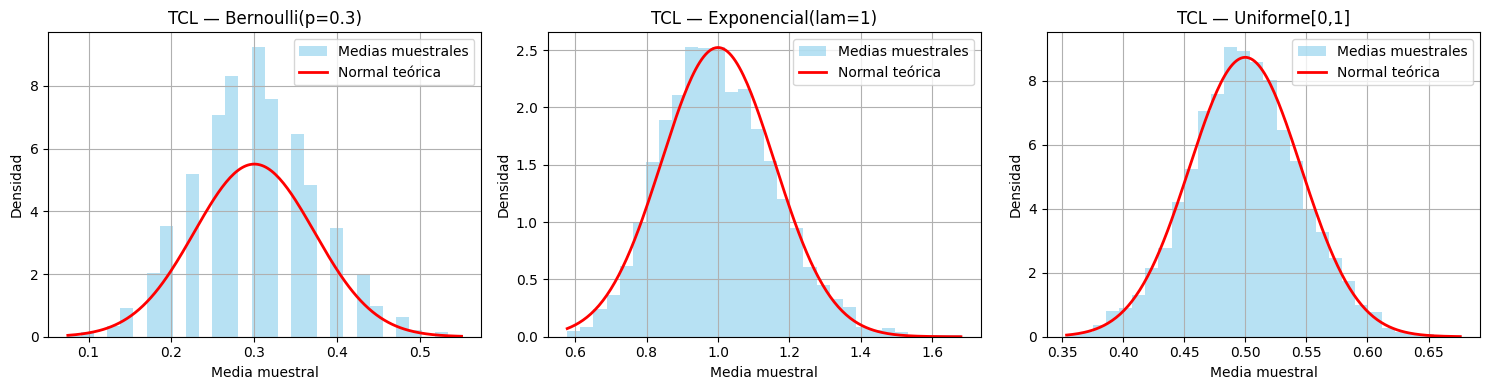

Cada media proviene de una muestra de tamaño n = 40 (5000 medias por caso).


In [21]:
# Teorema Central del Límite para tres distribuciones base
n = 40             # tamaño de cada muestra
num_muestras = 5000  # número de medias muestrales

# Definimos las distribuciones base con su media y varianza teóricas
casos = {
    'Bernoulli(p=0.3)':   dict(gen=lambda s: np.random.binomial(1, 0.3, s), mu=0.3,   var=0.3 * 0.7),
    'Exponencial(lam=1)': dict(gen=lambda s: np.random.exponential(1.0, s),  mu=1.0,   var=1.0),
    'Uniforme[0,1]':      dict(gen=lambda s: np.random.uniform(0, 1, s),     mu=0.5,   var=1 / 12),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, c) in zip(axes, casos.items()):
    # Generamos num_muestras medias, cada una de una muestra de tamaño n
    medias = np.array([c['gen'](n).mean() for _ in range(num_muestras)])
    ax.hist(medias, bins=30, density=True, alpha=0.6, color='skyblue', label='Medias muestrales')
    # Normal teórica: N(mu, var/n)
    mu_t, sd_t = c['mu'], np.sqrt(c['var'] / n)
    xx = np.linspace(medias.min(), medias.max(), 200)
    ax.plot(xx, st.norm(mu_t, sd_t).pdf(xx), 'r-', lw=2, label='Normal teórica')
    ax.set_title(f'TCL — {nombre}'); ax.set_xlabel('Media muestral'); ax.set_ylabel('Densidad')
    ax.legend()
plt.tight_layout(); plt.show()

print(f"Cada media proviene de una muestra de tamaño n = {n} ({num_muestras} medias por caso).")

El efecto del TCL es más marcado conforme aumenta el tamaño de muestra $n$. Lo ilustramos
partiendo de una distribución exponencial (muy asimétrica).


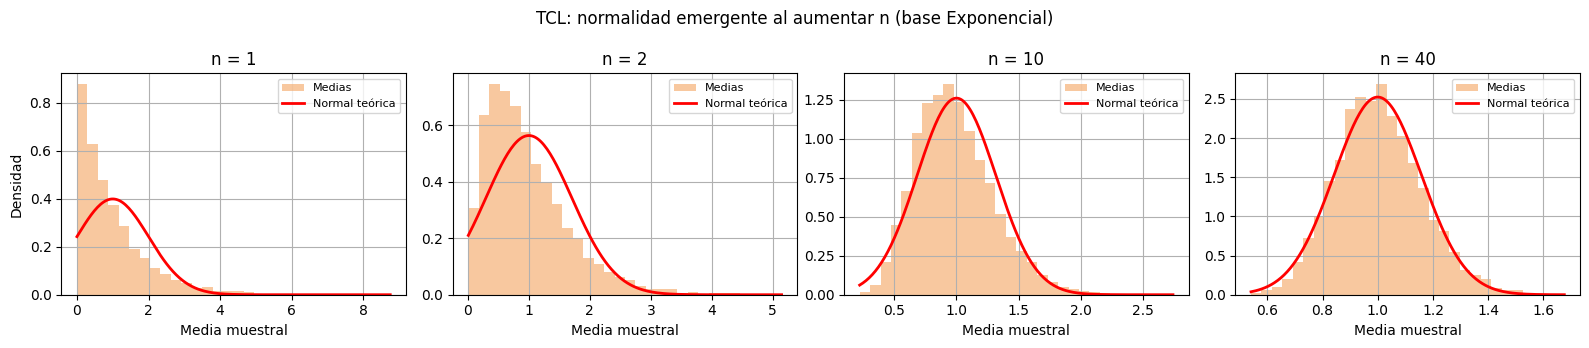

In [22]:
# Efecto del tamaño de muestra n en el TCL (base exponencial, muy asimétrica)
tam = [1, 2, 10, 40]
num_muestras = 5000

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, n in zip(axes, tam):
    medias = np.array([np.random.exponential(1.0, n).mean() for _ in range(num_muestras)])
    ax.hist(medias, bins=30, density=True, alpha=0.6, color='sandybrown', label='Medias')
    mu_t, sd_t = 1.0, np.sqrt(1.0 / n)
    xx = np.linspace(medias.min(), medias.max(), 200)
    ax.plot(xx, st.norm(mu_t, sd_t).pdf(xx), 'r-', lw=2, label='Normal teórica')
    ax.set_title(f'n = {n}'); ax.set_xlabel('Media muestral'); ax.legend(fontsize=8)
axes[0].set_ylabel('Densidad')
plt.suptitle('TCL: normalidad emergente al aumentar n (base Exponencial)')
plt.tight_layout(); plt.show()

# Conclusión

A lo largo de este notebook estudiamos el concepto de **variable aleatoria** y sus principales
distribuciones:

- Las **distribuciones discretas** (Uniforme discreta, Bernoulli, Binomial, Geométrica, Poisson,
  Binomial negativa e Hipergeométrica) modelan conteos y experimentos con resultados numerables.
- Las **distribuciones continuas** (Uniforme, Normal, Exponencial y Gamma, además de la Cauchy)
  modelan mediciones sobre intervalos de $\mathbb{R}$.
- El **método de la transformada inversa** permite generar realizaciones de una variable a partir
  de números uniformes, como mostramos con la Exponencial y la Cauchy.
- La **Función Generadora de Momentos** y la **Función Característica** caracterizan por completo
  una distribución y permiten obtener sus momentos (esperanza, varianza) mediante derivación.
- La **Ley de los Grandes Números** garantiza que el promedio muestral converge a la esperanza,
  lo que justifica el uso de simulaciones para estimar cantidades teóricas.
- El **Teorema Central del Límite** explica por qué la distribución Normal aparece de forma
  natural: la media de muchas variables i.i.d. es aproximadamente Normal, cualquiera que sea la
  distribución original.

En conjunto, estos resultados conectan la teoría de la probabilidad con la práctica de la
simulación: las distribuciones describen los fenómenos, la FGM y la FC los caracterizan, y la LGN
y el TCL fundamentan la inferencia estadística que abordaremos en el siguiente módulo.


# Bibliografía

- Rincón, L. (2014). *Introducción a la probabilidad*. Facultad de Ciencias, UNAM.
- Ross, S. M. (2014). *Introduction to Probability Models* (11th ed.). Academic Press.
- Ross, S. M. (2013). *Simulation* (5th ed.). Academic Press.
- Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). *Introduction to the Theory of Statistics*
  (3rd ed.). McGraw-Hill.
- Mendenhall, W., Beaver, R. J., & Beaver, B. M. (2010). *Introducción a la probabilidad y
  estadística* (13a ed.). Cengage Learning.
